<a href="https://colab.research.google.com/github/JoaoLopesMendes/Projeto-IA-ENEM-2023/blob/main/ProjetoIA_Enem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_453/1349266858.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


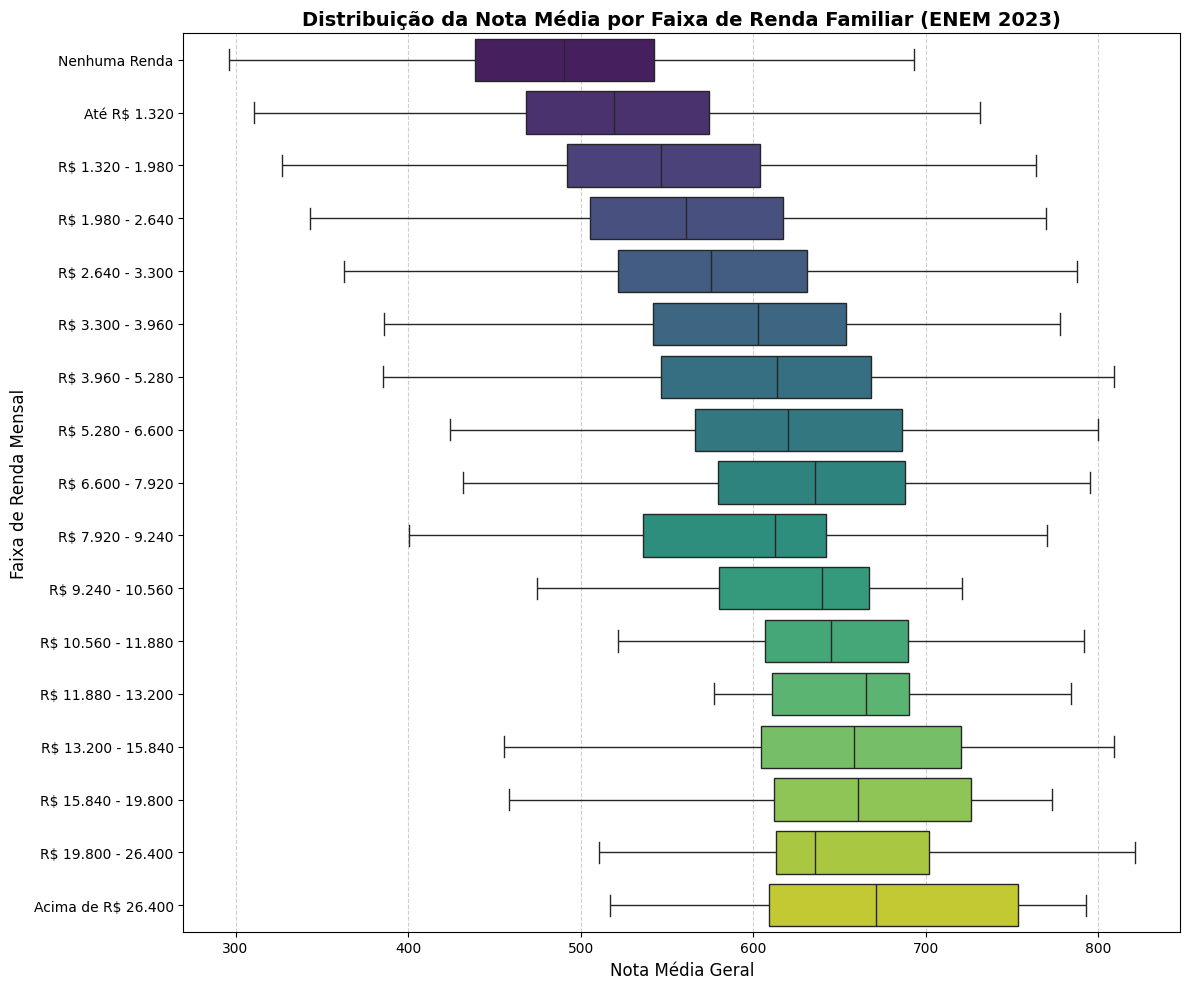

Sucesso! Dataset processado com descrições de renda.


In [3]:
# ==============================================================================
# PROJETO IA - 7°J SI - MACKENZIE
# Integrantes: Luis Felipe Cunha (RA: [10419514]) e João Pedro Lopes Mendes (RA: [10400793])
#
# SÍNTESE: Análise exploratória inicial dos Microdados ENEM 2023 focada no
# impacto socioeconômico (Renda Familiar) sobre o desempenho acadêmico.
#
# HISTÓRICO DE ALTERAÇÕES:
# Data       | Autor              | Descrição
# -----------|--------------------|----------------------------------------------------
# 22/03/2026 | Luis Felipe Cunha  | Mapeamento de categorias de renda e ajuste de eixos.
# ==============================================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. CARREGAMENTO DOS DADOS
caminho = '/srv/MICRODADOS_ENEM_2023.csv'
df = pd.read_csv(caminho, sep=';', encoding='latin-1', nrows=10000)

# 2. PRÉ-PROCESSAMENTO E FILTRAGEM
# Mantendo apenas quem compareceu a todas as provas
df_validos = df[
    (df['TP_PRESENCA_CN'] == 1) &
    (df['TP_PRESENCA_CH'] == 1) &
    (df['TP_PRESENCA_LC'] == 1) &
    (df['TP_PRESENCA_MT'] == 1)
].copy()

# Cálculo da Nota Média Geral
colunas_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
df_validos['NOTA_MEDIA'] = df_validos[colunas_notas].mean(axis=1)

# 3. MAPEAMENTO DA RENDA (Substituindo letras por valores reais)
dic_renda = {
    'A': 'Nenhuma Renda',
    'B': 'Até R$ 1.320',
    'C': 'R$ 1.320 - 1.980',
    'D': 'R$ 1.980 - 2.640',
    'E': 'R$ 2.640 - 3.300',
    'F': 'R$ 3.300 - 3.960',
    'G': 'R$ 3.960 - 5.280',
    'H': 'R$ 5.280 - 6.600',
    'I': 'R$ 6.600 - 7.920',
    'J': 'R$ 7.920 - 9.240',
    'K': 'R$ 9.240 - 10.560',
    'L': 'R$ 10.560 - 11.880',
    'M': 'R$ 11.880 - 13.200',
    'N': 'R$ 13.200 - 15.840',
    'O': 'R$ 15.840 - 19.800',
    'P': 'R$ 19.800 - 26.400',
    'Q': 'Acima de R$ 26.400'
}

# Aplicando o mapeamento em uma nova coluna
df_validos['RENDA_FAMILIAR'] = df_validos['Q006'].map(dic_renda)

# 4. ANÁLISE EXPLORATÓRIA (EDA) - BOXPLOT HORIZONTAL
plt.figure(figsize=(12, 10)) # Aumentado para melhor leitura do texto

# Ordenamos pelo Q006 original para manter a ordem lógica de valores (A->Q)
sns.boxplot(
    x='NOTA_MEDIA',
    y='RENDA_FAMILIAR',
    data=df_validos.sort_values('Q006'),
    palette='viridis',
    showfliers=False
)

# 5. FORMATAÇÃO padrão TCC
plt.title('Distribuição da Nota Média por Faixa de Renda Familiar (ENEM 2023)', fontsize=14, fontweight='bold')
plt.xlabel('Nota Média Geral', fontsize=12)
plt.ylabel('Faixa de Renda Mensal', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 6. EXPORTAÇÃO PARA O GITHUB
df_validos.to_csv('amostra_enem_n1.csv', index=False)
print("Sucesso! Dataset processado com descrições de renda.")